# Pretrained model Roberta - Fake News Detector - LIAR dataset

Pobieramy output z notatnika z przygotowaniem datasetu:

In [1]:
from google.colab import drive
import os
drive.mount('/content/drive')

CACHE_DIR = '/content/drive/MyDrive/fakenews_cache'
DATA_DIR    = os.path.join(CACHE_DIR, 'data')
TOK_DIR     = os.path.join(CACHE_DIR, 'tokenized')
MODEL_DIR_2 = os.path.join(CACHE_DIR, 'model_roberta_2cl')
MODEL_DIR_6 = os.path.join(CACHE_DIR, 'model_roberta_6cl')
HF_CACHE    = os.path.join(CACHE_DIR, 'hf_cache')

os.environ['HF_HOME'] = HF_CACHE
os.environ['TRANSFORMERS_CACHE'] = HF_CACHE

print('TOK_DIR:', os.listdir(TOK_DIR))

Mounted at /content/drive
TOK_DIR: ['train_2cl.pt', 'valid_2cl.pt', 'test_2cl.pt', 'train_6cl.pt', 'valid_6cl.pt', 'test_6cl.pt', 'y_train_2cl.pt', 'y_valid_2cl.pt', 'y_test_2cl.pt', 'y_train_6cl.pt', 'y_valid_6cl.pt', 'y_test_6cl.pt', 'df_train_2cl.parquet', 'df_valid_2cl.parquet', 'df_test_2cl.parquet', 'df_train_6cl.parquet', 'df_valid_6cl.parquet', 'df_test_6cl.parquet']


Konfiguracja dla latwego przechodzenia miedzy wersjami z klasyfikacja binarna i 6 klasami; cachowanie modelu z unikalnoscia per config

In [2]:
%pip install -q transformers torch

In [13]:
VERSION = '2cl'           # '2cl' albo '6cl'
MODEL_NAME = 'roberta-large'
EPOCHS = 7
LR = 2e-6
BATCH_SIZE  = 8
USE_CLASS_WEIGHTS  = True
SEED = 42

NUM_LABELS = 2 if VERSION == '2cl' else 6
MODEL_DIR  = (MODEL_DIR_2 if VERSION == '2cl' else MODEL_DIR_6) + f'_{MODEL_NAME}_lr{LR}_e{EPOCHS}'
os.makedirs(MODEL_DIR, exist_ok=True)
print(f'VERSION={VERSION}  MODEL={MODEL_NAME}  NUM_LABELS={NUM_LABELS}')
print('Model bedzie zapisany w:', MODEL_DIR)

VERSION=2cl  MODEL=roberta-large  NUM_LABELS=2
Model bedzie zapisany w: /content/drive/MyDrive/fakenews_cache/model_roberta_2cl_roberta-large_lr2e-06_e7


Ładowanie danych z notatnika z preprocessingiem:

In [4]:
import torch
import pandas as pd

def load_pt(name):
    return torch.load(os.path.join(TOK_DIR, name), weights_only=False)

enc_train = load_pt(f'train_{VERSION}.pt')
enc_valid = load_pt(f'valid_{VERSION}.pt')
enc_test  = load_pt(f'test_{VERSION}.pt')

y_train = load_pt(f'y_train_{VERSION}.pt')
y_valid = load_pt(f'y_valid_{VERSION}.pt')
y_test  = load_pt(f'y_test_{VERSION}.pt')

df_test = pd.read_parquet(os.path.join(TOK_DIR, f'df_test_{VERSION}.parquet'))

print('train tokens:', enc_train['input_ids'].shape)
print('y_train rozklad:', torch.unique(y_train, return_counts=True))

train tokens: torch.Size([10240, 128])
y_train rozklad: (tensor([0, 1]), tensor([4488, 5752]))


Pre trained model roberta-large; jest lepszy od bert  poniewaz posiada 10x wiecej danych i stosuje dynamiczne maskowanie

In [5]:
from transformers import RobertaForSequenceClassification, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model_roberta = RobertaForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS)
print(f'zaladowano: {MODEL_NAME}, num_labels={NUM_LABELS}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-large
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


zaladowano: roberta-large, num_labels=2


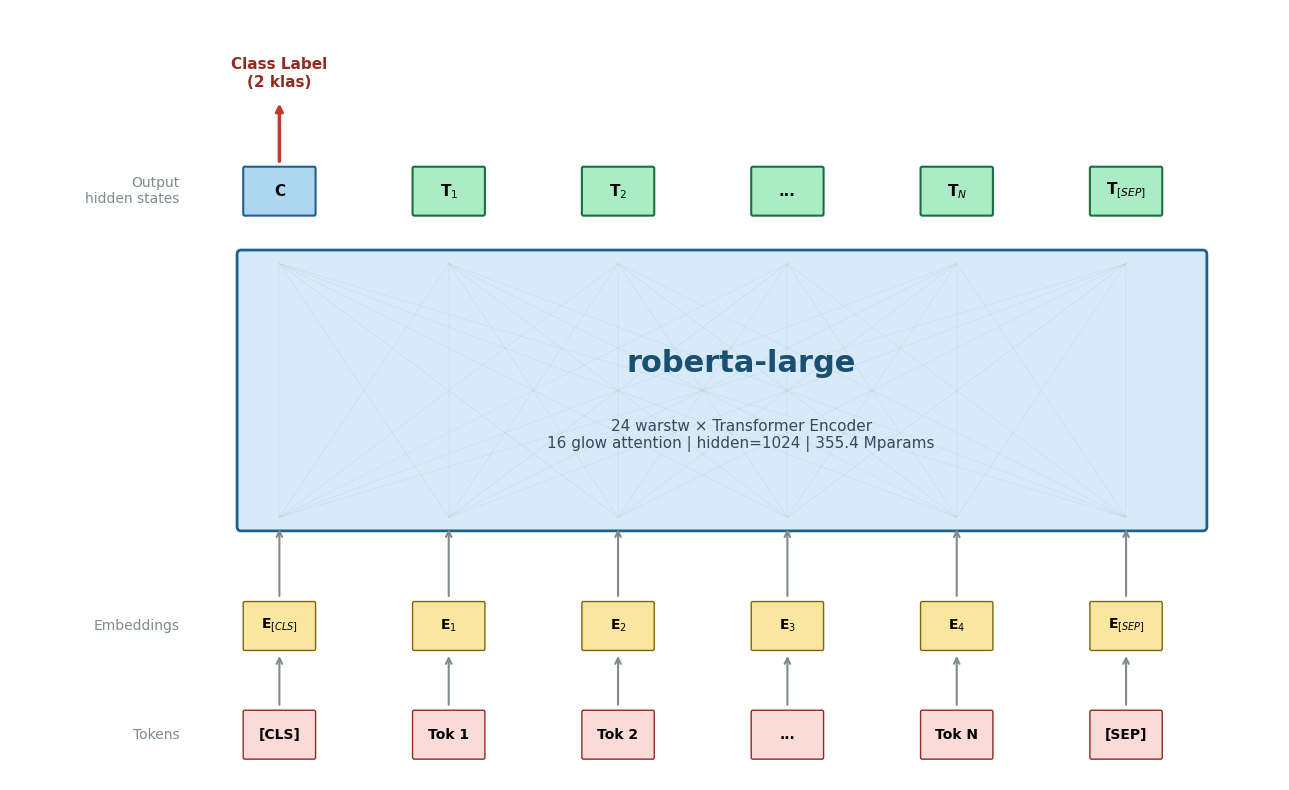

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def cp(m): return sum(p.numel() for p in m.parameters())
total_p = cp(model_roberta)
n_layers = len(model_roberta.roberta.encoder.layer)
hidden = model_roberta.config.hidden_size
n_heads = model_roberta.config.num_attention_heads

fig, ax = plt.subplots(figsize=(13, 8))

# tokeny na dole
tok_labels = ['[CLS]', 'Tok 1', 'Tok 2', '...', 'Tok N', '[SEP]']
n_tok = len(tok_labels)
xs = np.linspace(1, 12, n_tok)
y_tok = 0.5
y_emb = 1.7
y_box_bot = 2.8
y_box_top = 5.8
y_out = 6.5
y_cls = 7.5

# tokeny
for x, lab in zip(xs, tok_labels):
    box = mpatches.FancyBboxPatch((x-0.45, y_tok-0.25), 0.9, 0.5,
                                    boxstyle='round,pad=0.02',
                                    facecolor='#fadbd8', edgecolor='#922b21')
    ax.add_patch(box)
    ax.text(x, y_tok, lab, ha='center', va='center', fontsize=10, fontweight='bold')

# strzalki tokeny -> embedding
for x in xs:
    ax.annotate('', xy=(x, y_emb-0.3), xytext=(x, y_tok+0.3),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='#7f8c8d'))

# embeddingi
for i, x in enumerate(xs):
    lab = f'E$_{{{tok_labels[i]}}}$' if '[' in tok_labels[i] else f'E$_{i}$'
    box = mpatches.FancyBboxPatch((x-0.45, y_emb-0.25), 0.9, 0.5,
                                    boxstyle='round,pad=0.02',
                                    facecolor='#f9e79f', edgecolor='#7d6608')
    ax.add_patch(box)
    ax.text(x, y_emb, lab, ha='center', va='center', fontsize=10, fontweight='bold')

# wielki box RoBERTa
big = mpatches.FancyBboxPatch((0.5, y_box_bot), 12.5, y_box_top-y_box_bot,
                                boxstyle='round,pad=0.05',
                                facecolor='#d6eaf8', edgecolor='#1f618d', linewidth=2)
ax.add_patch(big)
ax.text(7, (y_box_bot+y_box_top)/2 + 0.3, MODEL_NAME, ha='center', va='center',
        fontsize=22, fontweight='bold', color='#1b4f72')
ax.text(7, (y_box_bot+y_box_top)/2 - 0.5,
        f'{n_layers} warstw × Transformer Encoder\n{n_heads} glow attention | hidden={hidden} | {total_p/1e6:.1f} Mparams',ha='center', va='center', fontsize=11, color='#34495e')

# sieci przewodow (cienkie linie wewnatrz)
for x1 in xs:
    for x2 in xs:
        ax.plot([x1, x2], [y_box_bot+0.1, y_box_top-0.1],
                color='#aab7b8', lw=0.3, alpha=0.4, zorder=1)

# strzalki embedding -> box (z dolu boxa)
for x in xs:
    ax.annotate('', xy=(x, y_box_bot), xytext=(x, y_emb+0.3),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='#7f8c8d'))

# wyjsciowe T tokeny
out_labels = ['C', 'T$_1$', 'T$_2$', '...', 'T$_N$', 'T$_{[SEP]}$']
for x, lab in zip(xs, out_labels):
    color = '#aed6f1' if lab == 'C' else '#abebc6'
    edge  = '#1f618d' if lab == 'C' else '#196f3d'
    box = mpatches.FancyBboxPatch((x-0.45, y_out-0.25), 0.9, 0.5,
                                    boxstyle='round,pad=0.02',
                                    facecolor=color, edgecolor=edge, linewidth=1.5)
    ax.add_patch(box)
    ax.text(x, y_out, lab, ha='center', va='center', fontsize=11, fontweight='bold')

# strzalka z C do Class Label
ax.annotate('', xy=(xs[0], y_cls), xytext=(xs[0], y_out+0.3),
            arrowprops=dict(arrowstyle='->', lw=2.5, color='#c0392b'))
ax.text(xs[0], y_cls+0.3, f'Class Label\n({NUM_LABELS} klas)',
        ha='center', va='center', fontsize=11, fontweight='bold', color='#922b21')

# opisy z boku
ax.text(-0.3, y_tok, 'Tokens', ha='right', va='center', fontsize=10, color='#7f8c8d')
ax.text(-0.3, y_emb, 'Embeddings', ha='right', va='center', fontsize=10, color='#7f8c8d')
ax.text(-0.3, y_out, 'Output\nhidden states', ha='right', va='center', fontsize=10, color='#7f8c8d')

ax.set_xlim(-2.5, 14)
ax.set_ylim(0, 8.5)
ax.axis('off')
plt.tight_layout(); plt.show()

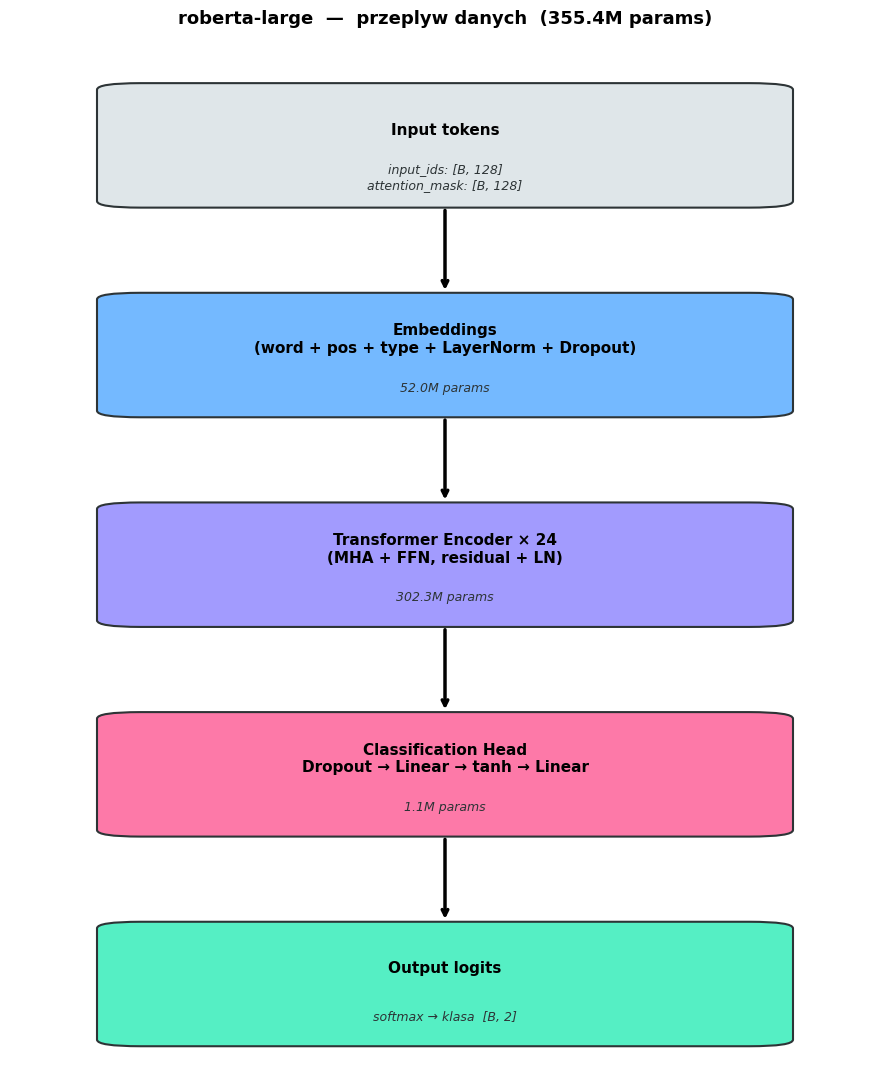

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def cp(m): return sum(p.numel() for p in m.parameters())
emb_p   = cp(model_roberta.roberta.embeddings)
enc_p   = cp(model_roberta.roberta.encoder)
head_p  = cp(model_roberta.classifier)
total_p = cp(model_roberta)
n_layers = len(model_roberta.roberta.encoder.layer)
hidden = model_roberta.config.hidden_size

blocks = [
    ('Input tokens',                                          'input_ids: [B, 128]\nattention_mask: [B, 128]',
'#dfe6e9'),
    ('Embeddings\n(word + pos + type + LayerNorm + Dropout)', f'{emb_p/1e6:.1f}M params',
'#74b9ff'),
    (f'Transformer Encoder × {n_layers}\n(MHA + FFN, residual + LN)', f'{enc_p/1e6:.1f}M params',
'#a29bfe'),
    ('Classification Head\nDropout → Linear → tanh → Linear', f'{head_p/1e6:.1f}M params',
'#fd79a8'),
    ('Output logits',                                         f'softmax → klasa  [B, {NUM_LABELS}]',
'#55efc4'),
]

fig, ax = plt.subplots(figsize=(9, 11))
y = 0
positions = []
for name, shape, color in blocks:
    rect = mpatches.FancyBboxPatch((0.15, y), 0.7, 0.85,
                                    boxstyle='round,pad=0.05',
                                    facecolor=color, edgecolor='#2d3436', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(0.5, y+0.55, name, ha='center', va='center', fontsize=11, fontweight='bold')
    ax.text(0.5, y+0.18, shape, ha='center', va='center', fontsize=9, color='#2d3436', style='italic')
    positions.append((y, y+0.85))
    y -= 1.6

for i in range(1, len(blocks)):
    ax.annotate('', xy=(0.5, positions[i][1]+0.05),
                xytext=(0.5, positions[i-1][0]-0.05),
                arrowprops=dict(arrowstyle='->', lw=2.5, color='black'))

ax.set_xlim(0, 1); ax.set_ylim(positions[-1][0]-0.3, 1.2)
ax.axis('off')
ax.set_title(f'{MODEL_NAME}  —  przeplyw danych  ({total_p/1e6:.1f}M params)',
              fontsize=13, fontweight='bold', pad=15)
plt.tight_layout(); plt.show()

data loadery:

In [8]:
class LiarDataset(torch.utils.data.Dataset):
    def __init__(self, enc, labels):
        self.enc = enc
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, i):
        return {
            'input_ids':      self.enc['input_ids'][i],
            'attention_mask': self.enc['attention_mask'][i],
            'labels':         self.labels[i]
        }

train_loader = torch.utils.data.DataLoader(LiarDataset(enc_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
valid_loader = torch.utils.data.DataLoader(LiarDataset(enc_valid, y_valid), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = torch.utils.data.DataLoader(LiarDataset(enc_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False)

## Trening modelu

Ze wzgledu na wyniki otrzymane w preprocesisngu dla klasyfikacji binarnej dodajemy wagi klas aby usunac nierownolicznosc miedzy true i false:

In [14]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, f1_score
import copy
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_roberta = model_roberta.to(device)

optimizer = AdamW(model_roberta.parameters(), lr=LR, weight_decay=0.1)
total_steps = len(train_loader) * EPOCHS
warmup_steps = len(train_loader)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

if USE_CLASS_WEIGHTS:
    counts = torch.bincount(y_train, minlength=NUM_LABELS).float()
    class_weights = (counts.sum() / (NUM_LABELS * counts)).to(device)
    print('class_weights:', class_weights.tolist())
else:
    class_weights = None
loss_fn = nn.CrossEntropyLoss(weight=class_weights) if class_weights is not None else nn.CrossEntropyLoss()

print(f'device={device}  EPOCHS={EPOCHS}  LR={LR}  BATCH={BATCH_SIZE}  total_steps={total_steps}')

class_weights: [1.1408199071884155, 0.8901251554489136]
device=cuda  EPOCHS=7  LR=2e-06  BATCH=8  total_steps=8960


## Petla treningowa z walidacja po kazdej epoce

Petla treningowa - w formie funkcji pod Optunę, cashowanie modelu na drive

In [15]:
from transformers import RobertaForSequenceClassification

def train_and_eval(epochs, lr, batch_size, weight_decay, use_class_weights,
                    model_name=MODEL_NAME, num_labels=NUM_LABELS, save_dir=None,
                    verbose=True, patience=2):
    """Trenuje swiezy model i zwraca (model, best_val_macroF1, history)."""
    import copy
    from torch.optim import AdamW
    from torch.cuda.amp import autocast
    from transformers import get_linear_schedule_with_warmup
    from sklearn.metrics import f1_score, accuracy_score
    import torch.nn as nn

    model = RobertaForSequenceClassification.from_pretrained(model_name, num_labels=num_labels).to(device)

    tr_loader = torch.utils.data.DataLoader(LiarDataset(enc_train, y_train), batch_size=batch_size, shuffle=True)
    va_loader = torch.utils.data.DataLoader(LiarDataset(enc_valid, y_valid), batch_size=batch_size, shuffle=False)

    opt = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    total = len(tr_loader) * epochs
    sched = get_linear_schedule_with_warmup(opt, num_warmup_steps=len(tr_loader), num_training_steps=total)

    if use_class_weights:
        cnt = torch.bincount(y_train, minlength=num_labels).float()
        cw = (cnt.sum() / (num_labels * cnt)).to(device)
        loss_fn = nn.CrossEntropyLoss(weight=cw, label_smoothing=0.1)
    else:
        loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

    history = {'train_loss': [], 'val_loss': [], 'val_macro_f1': []}
    best_f1, best_state, no_improve = 0.0, None, 0

    for e in range(epochs):
        model.train(); total_loss = 0
        for bi, batch in enumerate(tr_loader):
            ids = batch['input_ids'].to(device)
            am  = batch['attention_mask'].to(device)
            lab = batch['labels'].to(device)
            opt.zero_grad()
            with autocast(dtype=torch.bfloat16):
                logits = model(ids, attention_mask=am).logits
                loss = loss_fn(logits, lab)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sched.step()
            total_loss += loss.item()
            if verbose and bi % 100 == 0:
                print(f'  e{e+1} b{bi}/{len(tr_loader)} loss={loss.item():.4f}')

        # walidacja (z lossem)
        model.eval(); vp, vl = [], []
        val_loss_total = 0
        with torch.no_grad():
            for batch in va_loader:
                ids = batch['input_ids'].to(device)
                am  = batch['attention_mask'].to(device)
                lab = batch['labels'].to(device)
                with autocast(dtype=torch.bfloat16):
                    logits = model(ids, attention_mask=am).logits
                    val_loss_total += loss_fn(logits, lab).item()
                p = torch.argmax(logits, dim=1)
                vp.extend(p.cpu().numpy()); vl.extend(lab.cpu().numpy())

        f1 = f1_score(vl, vp, average='macro')
        acc = accuracy_score(vl, vp)
        tr_loss = total_loss / len(tr_loader)
        va_loss = val_loss_total / len(va_loader)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['val_macro_f1'].append(f1)

        improved = f1 > best_f1
        if verbose:
            mark = ' <-- best!' if improved else ''
            print(f'Epoch {e+1}/{epochs} | train_loss={tr_loss:.4f} | val_loss={va_loss:.4f} | val_acc={acc:.4f}|val_macroF1={f1:.4f}{mark}')

        if improved:
            best_f1 = f1
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                if verbose:
                    print(f'Early stop: brak poprawy przez {patience} epoki (best F1={best_f1:.4f})')
                break

    model.load_state_dict(best_state)
    if save_dir:
        model.save_pretrained(save_dir)
        tokenizer.save_pretrained(save_dir)
        print(f'zapisano model: {save_dir}  best_val_macroF1={best_f1:.4f}')
    return model, best_f1, history


# === BASELINE ===
if os.path.exists(os.path.join(MODEL_DIR, 'config.json')):
    print(f'cache hit: ladowanie modelu z {MODEL_DIR}')
    model_roberta = RobertaForSequenceClassification.from_pretrained(MODEL_DIR).to(device)
    baseline_f1 = None
    history = None
else:
    print('brak cache - trenuje baseline...')
    model_roberta, baseline_f1, history = train_and_eval(
        epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE, weight_decay=0.1,
        use_class_weights=USE_CLASS_WEIGHTS, save_dir=MODEL_DIR)
    print(f'\nBaseline macro-F1 (val): {baseline_f1:.4f}')

brak cache - trenuje baseline...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-large
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_430/2120939286.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.bfloat16):


  e1 b0/1280 loss=0.7419
  e1 b100/1280 loss=0.6448
  e1 b200/1280 loss=0.7008
  e1 b300/1280 loss=0.6874
  e1 b400/1280 loss=0.7275
  e1 b500/1280 loss=0.7066
  e1 b600/1280 loss=0.6388
  e1 b700/1280 loss=0.6839
  e1 b800/1280 loss=0.6427
  e1 b900/1280 loss=0.7408
  e1 b1000/1280 loss=0.7354
  e1 b1100/1280 loss=0.7105
  e1 b1200/1280 loss=0.6783


/tmp/ipykernel_430/2120939286.py:58: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.bfloat16):


...

  e6 b100/1280 loss=0.4559
  e6 b200/1280 loss=0.5436
  e6 b300/1280 loss=0.4087
  e6 b400/1280 loss=0.4139
  e6 b500/1280 loss=0.4172
  e6 b600/1280 loss=0.8390
  e6 b700/1280 loss=0.2525
  e6 b800/1280 loss=0.3906
  e6 b900/1280 loss=0.3807
  e6 b1000/1280 loss=0.4026
  e6 b1100/1280 loss=0.7188
  e6 b1200/1280 loss=0.7267


/tmp/ipykernel_430/2120939286.py:58: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.bfloat16):


Epoch 6/7 | train_loss=0.5106 | val_loss=0.6689 | val_acc=0.7111|val_macroF1=0.7009
Early stop: brak poprawy przez 2 epoki (best F1=0.7189)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

zapisano model: /content/drive/MyDrive/fakenews_cache/model_roberta_2cl_roberta-large_lr2e-06_e7  best_val_macroF1=0.7189

Baseline macro-F1 (val): 0.7189


## Ewaluacja na zbiorze testowym

=== Test: 2cl / roberta-large ===
accuracy           : 0.7380
balanced accuracy  : 0.7257
precision (macro)  : 0.7369   (weighted): 0.7374
recall    (macro)  : 0.7257   (weighted): 0.7380
macro-F1           : 0.7283   weighted-F1: 0.7348

              precision    recall  f1-score   support

        fake      0.733     0.629     0.677       553
        real      0.741     0.822     0.780       714

    accuracy                          0.738      1267
   macro avg      0.737     0.726     0.728      1267
weighted avg      0.737     0.738     0.735      1267

ROC AUC: 0.8060


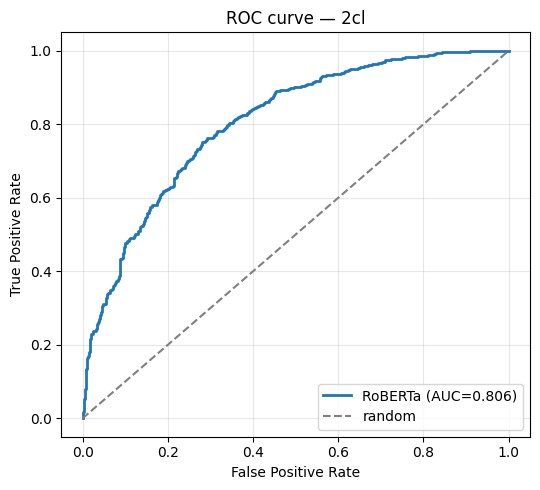


Confusion matrix:
      fake  real
fake   348   205
real   127   587


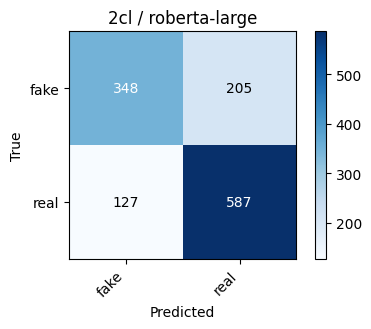

In [11]:
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score,
    balanced_accuracy_score, precision_score, recall_score,
    roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

target_names = ['fake', 'real'] if VERSION == '2cl' else ['pants-fire', 'false', 'barely-true', 'half-true',
'mostly-true', 'true']

model_roberta.eval()
test_preds, test_labels, test_probs = [], [], []
with torch.no_grad():
    for batch in test_loader:
        ids = batch['input_ids'].to(device)
        am  = batch['attention_mask'].to(device)
        logits = model_roberta(ids, attention_mask=am).logits
        probs  = torch.softmax(logits, dim=1)
        p      = torch.argmax(logits, dim=1)
        test_preds.extend(p.cpu().numpy())
        test_labels.extend(batch['labels'].numpy())
        test_probs.extend(probs.cpu().numpy())

test_preds  = np.array(test_preds)
test_labels = np.array(test_labels)
test_probs  = np.array(test_probs)

acc     = accuracy_score(test_labels, test_preds)
bal_acc = balanced_accuracy_score(test_labels, test_preds)
prec_m  = precision_score(test_labels, test_preds, average='macro', zero_division=0)
rec_m   = recall_score(test_labels, test_preds, average='macro', zero_division=0)
mf1     = f1_score(test_labels, test_preds, average='macro')
prec_w  = precision_score(test_labels, test_preds, average='weighted', zero_division=0)
rec_w   = recall_score(test_labels, test_preds, average='weighted', zero_division=0)
wf1     = f1_score(test_labels, test_preds, average='weighted')

print(f'=== Test: {VERSION} / {MODEL_NAME} ===')
print(f'accuracy           : {acc:.4f}')
print(f'balanced accuracy  : {bal_acc:.4f}')
print(f'precision (macro)  : {prec_m:.4f}   (weighted): {prec_w:.4f}')
print(f'recall    (macro)  : {rec_m:.4f}   (weighted): {rec_w:.4f}')
print(f'macro-F1           : {mf1:.4f}   weighted-F1: {wf1:.4f}')
print()
print(classification_report(test_labels, test_preds, target_names=target_names, digits=3, zero_division=0))

# --- ROC AUC ---
if VERSION == '2cl':
    auc = roc_auc_score(test_labels, test_probs[:, 1])
    fpr, tpr, _ = roc_curve(test_labels, test_probs[:, 1])
    print(f'ROC AUC: {auc:.4f}')

    plt.figure(figsize=(5.5, 5))
    plt.plot(fpr, tpr, label=f'RoBERTa (AUC={auc:.3f})', color='tab:blue', lw=2)
    plt.plot([0, 1], [0, 1], '--', color='gray', label='random')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'ROC curve — {VERSION}')
    plt.grid(alpha=0.3); plt.legend(loc='lower right')
    plt.tight_layout(); plt.show()
else:
    auc_macro    = roc_auc_score(test_labels, test_probs, multi_class='ovr', average='macro')
    auc_weighted = roc_auc_score(test_labels, test_probs, multi_class='ovr', average='weighted')
    print(f'ROC AUC (one-vs-rest, macro):    {auc_macro:.4f}')
    print(f'ROC AUC (one-vs-rest, weighted): {auc_weighted:.4f}')

    plt.figure(figsize=(7, 6))
    for c in range(len(target_names)):
        y_bin = (test_labels == c).astype(int)
        fpr, tpr, _ = roc_curve(y_bin, test_probs[:, c])
        auc_c = roc_auc_score(y_bin, test_probs[:, c])
        plt.plot(fpr, tpr, label=f'{target_names[c]} (AUC={auc_c:.3f})', lw=1.5)
    plt.plot([0, 1], [0, 1], '--', color='gray', label='random')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'ROC curves (one-vs-rest) — {VERSION}')
    plt.grid(alpha=0.3); plt.legend(loc='lower right', fontsize=8)
    plt.tight_layout(); plt.show()

# --- confusion matrix ---
cm = confusion_matrix(test_labels, test_preds)
print('\nConfusion matrix:')
print(pd.DataFrame(cm, index=target_names, columns=target_names))

fig, ax = plt.subplots(figsize=(1.2*len(target_names)+2, 1.2*len(target_names)+1))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(target_names))); ax.set_xticklabels(target_names, rotation=45, ha='right')
ax.set_yticks(range(len(target_names))); ax.set_yticklabels(target_names)
for i in range(len(target_names)):
    for j in range(len(target_names)):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black')
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(f'{VERSION} / {MODEL_NAME}')
fig.colorbar(im); fig.tight_layout(); plt.show()

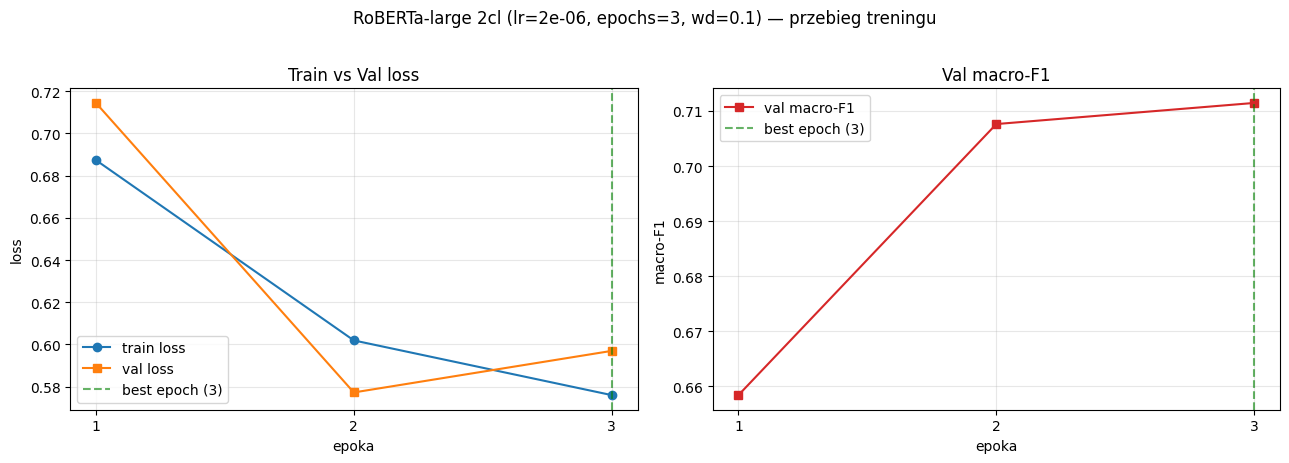

Best epoch: 3 | val_F1=0.7115 | val_loss=0.5969
val_loss: 0.714 -> 0.597 | train_loss: 0.687 ->0.576


In [12]:
import matplotlib.pyplot as plt

if history is None:
    print("history is None (prawdopodobnie cache hit) — nic do narysowania")
else:
    epochs_x   = list(range(1, len(history['train_loss']) + 1))
    train_loss = history['train_loss']
    val_loss   = history['val_loss']
    val_f1     = history['val_macro_f1']
    best_epoch = max(range(len(val_f1)), key=lambda i: val_f1[i]) + 1

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    ax = axes[0]
    ax.plot(epochs_x, train_loss, marker='o', label='train loss', color='tab:blue')
    ax.plot(epochs_x, val_loss,   marker='s', label='val loss',   color='tab:orange')
    ax.axvline(best_epoch, color='green', linestyle='--', alpha=0.6, label=f'best epoch ({best_epoch})')
    ax.set_xlabel('epoka'); ax.set_ylabel('loss')
    ax.set_title('Train vs Val loss')
    ax.set_xticks(epochs_x)
    ax.grid(alpha=0.3); ax.legend()

    ax = axes[1]
    ax.plot(epochs_x, val_f1, marker='s', label='val macro-F1', color='tab:red')
    ax.axvline(best_epoch, color='green', linestyle='--', alpha=0.6, label=f'best epoch ({best_epoch})')
    ax.set_xlabel('epoka'); ax.set_ylabel('macro-F1')
    ax.set_title('Val macro-F1')
    ax.set_xticks(epochs_x)
    ax.grid(alpha=0.3); ax.legend()

    plt.suptitle(f'RoBERTa-large {VERSION} (lr={LR}, epochs={EPOCHS}, wd=0.1) — przebieg treningu', y=1.02)
    plt.tight_layout()
    plt.show()

    print(f'Best epoch: {best_epoch} | val_F1={val_f1[best_epoch-1]:.4f} | val_loss={val_loss[best_epoch-1]:.4f}')
    print(f'val_loss: {val_loss[0]:.3f} -> {val_loss[-1]:.3f} | train_loss: {train_loss[0]:.3f} ->{train_loss[-1]:.3f}')

## Optuna do dostosowania hiperparametrow:

In [16]:
!pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 18.2 MB/s eta 0:00:00


In [18]:
import optuna
import json

OPTUNA_DIR = os.path.join(CACHE_DIR, 'optuna_studies')
os.makedirs(OPTUNA_DIR, exist_ok=True)
STUDY_DB   = f'sqlite:///{OPTUNA_DIR}/roberta_{VERSION}.db'
STUDY_NAME = f'roberta_{VERSION}_{MODEL_NAME}'

N_TRIALS = 20

def objective(trial):
    lr           = trial.suggest_float('lr', 5e-7, 1e-5, log=True)
    weight_decay = trial.suggest_float('weight_decay', 0.0, 0.3)
    epochs       = trial.suggest_categorical('epochs', [3, 5, 7])
    batch_size   = trial.suggest_categorical('batch_size', [8, 16])

    print(f'\n=== Trial {trial.number}: lr={lr:.2e}, wd={weight_decay:.3f}, '
          f'epochs={epochs}, bs={batch_size} ===')

    _, best_f1, history = train_and_eval(
        epochs=epochs, lr=lr, batch_size=batch_size,
        weight_decay=weight_decay, use_class_weights=USE_CLASS_WEIGHTS,
        save_dir=None, verbose=False
    )

    for e, f1 in enumerate(history['val_macro_f1']):
        trial.report(f1, e)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return best_f1

study = optuna.create_study(
    study_name=STUDY_NAME,
    storage=STUDY_DB,
    direction='maximize',
    load_if_exists=True,
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=1),
    sampler=optuna.samplers.TPESampler(seed=SEED),
)

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print('\n=========== WYNIKI OPTUNY ===========')
print(f'Najlepszy F1 (val): {study.best_value:.4f}')
print(f'Najlepsze hiperparametry: {study.best_params}')

with open(os.path.join(OPTUNA_DIR, f'best_params_{VERSION}.json'), 'w') as f:
    json.dump(study.best_params, f, indent=2)



[I 2026-06-14 14:19:32,427] A new study created in RDB with name: roberta_2cl_roberta-large


  0%|          | 0/20 [00:00<?, ?it/s]


=== Trial 0: lr=1.54e-06, wd=0.285, epochs=3, bs=8 ===


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-large
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_430/2120939286.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.bfloat16):


...

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-large
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_430/2120939286.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.bfloat16):


[I 2026-06-14 16:51:46,982] Trial 18 pruned. 

=== Trial 19: lr=7.21e-06, wd=0.230, epochs=3, bs=8 ===


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-large
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_430/2120939286.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.bfloat16):


[I 2026-06-14 16:58:12,864] Trial 19 finished with value: 0.7275653940765462 and parameters: {'lr': 7.206965039922567e-06, 'weight_decay': 0.23002695512927698, 'epochs': 3, 'batch_size': 8}. Best is trial 15 with value: 0.7370110995278101.

=========== WYNIKI OPTUNY ===========
Najlepszy F1 (val): 0.7370
Najlepsze hiperparametry: {'lr': 5.787797864410372e-06, 'weight_decay': 0.12433205811463252, 'epochs': 5, 'batch_size': 8}


In [19]:
best = study.best_params
FINAL_DIR = MODEL_DIR + '_optuna_best'
os.makedirs(FINAL_DIR, exist_ok=True)
print(f'Trenuje finalny model z: {best}')

model_roberta, baseline_f1, history = train_and_eval(
    epochs=best['epochs'],
    lr=best['lr'],
    batch_size=best['batch_size'],
    weight_decay=best['weight_decay'],
    use_class_weights=USE_CLASS_WEIGHTS,
    save_dir=FINAL_DIR,
    verbose=True
)
print(f'\nFinalny baseline macro-F1 (val): {baseline_f1:.4f}')

Trenuje finalny model z: {'lr': 5.787797864410372e-06, 'weight_decay': 0.12433205811463252, 'epochs': 5, 'batch_size': 8}


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-large
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_430/2120939286.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.bfloat16):


  e1 b0/1280 loss=0.6800
  e1 b100/1280 loss=0.6650
  e1 b200/1280 loss=0.6991
  e1 b300/1280 loss=0.7213
  e1 b400/1280 loss=0.6929
  e1 b500/1280 loss=0.7875
  e1 b600/1280 loss=0.6500
  e1 b700/1280 loss=0.5552
  e1 b800/1280 loss=0.7506
  e1 b900/1280 loss=0.4294
  e1 b1000/1280 loss=0.6249
  e1 b1100/1280 loss=0.5976
  e1 b1200/1280 loss=0.8455


/tmp/ipykernel_430/2120939286.py:58: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.bfloat16):


...

  e5 b100/1280 loss=0.2489
  e5 b200/1280 loss=0.4249
  e5 b300/1280 loss=0.5642
  e5 b400/1280 loss=0.3733
  e5 b500/1280 loss=0.3624
  e5 b600/1280 loss=0.2891
  e5 b700/1280 loss=0.5602
  e5 b800/1280 loss=0.2851
  e5 b900/1280 loss=0.2174
  e5 b1000/1280 loss=0.2891
  e5 b1100/1280 loss=0.2343
  e5 b1200/1280 loss=0.9010


/tmp/ipykernel_430/2120939286.py:58: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.bfloat16):


Epoch 5/5 | train_loss=0.4409 | val_loss=0.6498 | val_acc=0.7407|val_macroF1=0.7378


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

zapisano model: /content/drive/MyDrive/fakenews_cache/model_roberta_2cl_roberta-large_lr2e-06_e7_optuna_best  best_val_macroF1=0.7435

Finalny baseline macro-F1 (val): 0.7435


#Roberta large - 6 klas

Przełączamy konfigurację na 6 kl:

In [20]:
VERSION = '6cl'
NUM_LABELS = 6
MODEL_DIR  = MODEL_DIR_6 + f'_{MODEL_NAME}_6cl_optuna'
os.makedirs(MODEL_DIR, exist_ok=True)
print(f'VERSION={VERSION}  NUM_LABELS={NUM_LABELS}  MODEL_DIR={MODEL_DIR}')

VERSION=6cl  NUM_LABELS=6  MODEL_DIR=/content/drive/MyDrive/fakenews_cache/model_roberta_6cl_roberta-large_6cl_optuna


Wczytujemy wczesniej ztokenizowane dane

In [21]:
enc_train = load_pt(f'train_{VERSION}.pt')
enc_valid = load_pt(f'valid_{VERSION}.pt')
enc_test  = load_pt(f'test_{VERSION}.pt')

y_train = load_pt(f'y_train_{VERSION}.pt')
y_valid = load_pt(f'y_valid_{VERSION}.pt')
y_test  = load_pt(f'y_test_{VERSION}.pt')

df_test = pd.read_parquet(os.path.join(TOK_DIR, f'df_test_{VERSION}.parquet'))

print('train tokens:', enc_train['input_ids'].shape)
print('y_train rozklad:', torch.unique(y_train, return_counts=True))

train tokens: torch.Size([10240, 128])
y_train rozklad: (tensor([0, 1, 2, 3, 4, 5]), tensor([ 839, 1995, 1654, 2114, 1962, 1676]))


DataLoadery:

In [22]:
train_loader = torch.utils.data.DataLoader(LiarDataset(enc_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
valid_loader = torch.utils.data.DataLoader(LiarDataset(enc_valid, y_valid), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = torch.utils.data.DataLoader(LiarDataset(enc_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False)
print('loaders ok')

loaders ok


In [26]:
  import json

  #best params z Optuny 2kl (zapisane przez komorke Optuny)
  with open(os.path.join(OPTUNA_DIR, 'best_params_2cl.json')) as f:
      best_2cl = json.load(f)
  print(f'Best params z 2cl: {best_2cl}')

  # 6kl jest trudniejsze -> dajemy wiecej epok
  EPOCHS_6CL = max(best_2cl['epochs'], 7)
  print(f'EPOCHS dla 6cl: {EPOCHS_6CL}')

  model_roberta, baseline_f1, history = train_and_eval(
      epochs=EPOCHS_6CL,
      lr=best_2cl['lr'],
      batch_size=best_2cl['batch_size'],
      weight_decay=best_2cl['weight_decay'],
      use_class_weights=USE_CLASS_WEIGHTS,
      num_labels=6,
      save_dir=MODEL_DIR,
      verbose=True
  )
  print(f'\n6cl macro-F1 (val): {baseline_f1:.4f}')

Best params z 2cl: {'lr': 5.787797864410372e-06, 'weight_decay': 0.12433205811463252, 'epochs': 5, 'batch_size': 8}
EPOCHS dla 6cl: 7


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-large
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_430/2120939286.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.bfloat16):


  e1 b0/1280 loss=1.7815
  e1 b100/1280 loss=1.7478
  e1 b200/1280 loss=1.7764
  e1 b300/1280 loss=1.8652
  e1 b400/1280 loss=1.9196
  e1 b500/1280 loss=1.7602
  e1 b600/1280 loss=1.8466
  e1 b700/1280 loss=1.7503
  e1 b800/1280 loss=1.7805
  e1 b900/1280 loss=1.8149
  e1 b1000/1280 loss=1.6366
  e1 b1100/1280 loss=1.7888
  e1 b1200/1280 loss=1.5880


/tmp/ipykernel_430/2120939286.py:58: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.bfloat16):


...

  e5 b100/1280 loss=1.3907
  e5 b200/1280 loss=1.2475
  e5 b300/1280 loss=1.2383
  e5 b400/1280 loss=1.2525
  e5 b500/1280 loss=1.0094
  e5 b600/1280 loss=0.8538
  e5 b700/1280 loss=1.1359
  e5 b800/1280 loss=1.5416
  e5 b900/1280 loss=1.1125
  e5 b1000/1280 loss=1.1461
  e5 b1100/1280 loss=1.2505
  e5 b1200/1280 loss=1.2849


/tmp/ipykernel_430/2120939286.py:58: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.bfloat16):


Epoch 5/7 | train_loss=1.3436 | val_loss=1.6525 | val_acc=0.3512|val_macroF1=0.3593
Early stop: brak poprawy przez 2 epoki (best F1=0.3754)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

zapisano model: /content/drive/MyDrive/fakenews_cache/model_roberta_6cl_roberta-large_6cl_optuna  best_val_macroF1=0.3754

6cl macro-F1 (val): 0.3754


Ewaluacja modelu 6-klasowego

=== Test: 6cl / roberta-large ===
accuracy           : 0.3567
balanced accuracy  : 0.3563
precision (macro)  : 0.3652   (weighted): 0.3619
recall    (macro)  : 0.3563   (weighted): 0.3567
macro-F1           : 0.3585   weighted-F1: 0.3572

              precision    recall  f1-score   support

  pants-fire      0.423     0.359     0.388        92
       false      0.490     0.406     0.444       249
 barely-true      0.253     0.236     0.244       212
   half-true      0.348     0.328     0.338       265
 mostly-true      0.331     0.382     0.355       241
        true      0.346     0.428     0.383       208

    accuracy                          0.357      1267
   macro avg      0.365     0.356     0.359      1267
weighted avg      0.362     0.357     0.357      1267


Confusion matrix:
             pants-fire  false  barely-true  half-true  mostly-true  true
pants-fire           33     35           13          5            3     3
false                23    101           51        

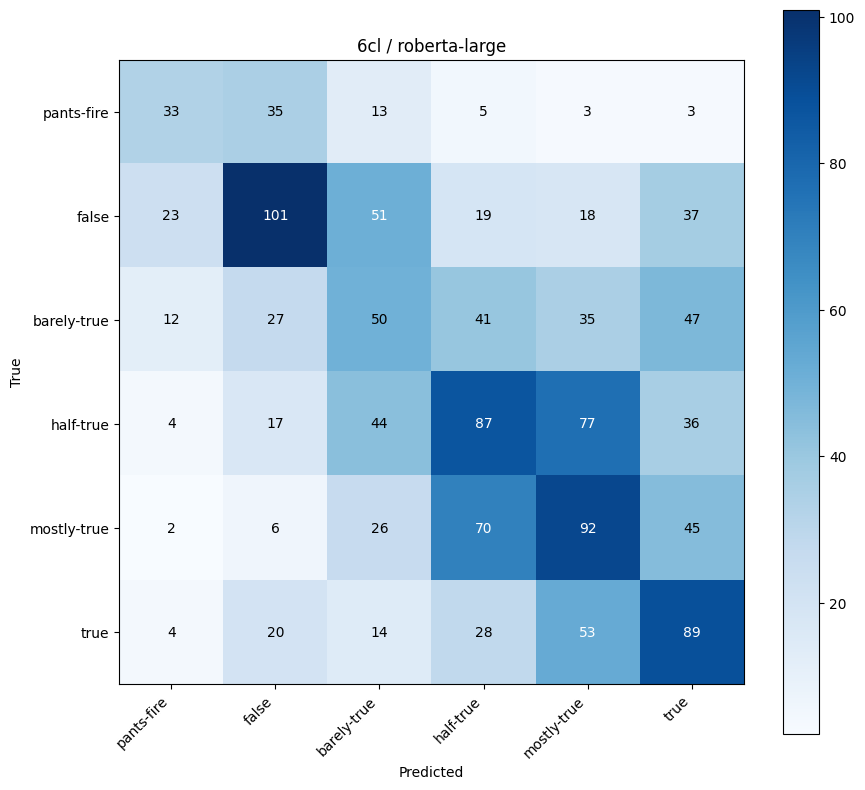

In [27]:
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score,
    balanced_accuracy_score, precision_score, recall_score,
    roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

target_names = ['fake', 'real'] if VERSION == '2cl' else ['pants-fire', 'false', 'barely-true', 'half-true',
'mostly-true', 'true']

model_roberta.eval()
test_preds, test_labels, test_probs = [], [], []
with torch.no_grad():
    for batch in test_loader:
        ids = batch['input_ids'].to(device)
        am  = batch['attention_mask'].to(device)
        logits = model_roberta(ids, attention_mask=am).logits
        probs  = torch.softmax(logits, dim=1)
        p      = torch.argmax(logits, dim=1)
        test_preds.extend(p.cpu().numpy())
        test_labels.extend(batch['labels'].numpy())
        test_probs.extend(probs.cpu().numpy())

test_preds  = np.array(test_preds)
test_labels = np.array(test_labels)
test_probs  = np.array(test_probs)

acc     = accuracy_score(test_labels, test_preds)
bal_acc = balanced_accuracy_score(test_labels, test_preds)
prec_m  = precision_score(test_labels, test_preds, average='macro', zero_division=0)
rec_m   = recall_score(test_labels, test_preds, average='macro', zero_division=0)
mf1     = f1_score(test_labels, test_preds, average='macro')
prec_w  = precision_score(test_labels, test_preds, average='weighted', zero_division=0)
rec_w   = recall_score(test_labels, test_preds, average='weighted', zero_division=0)
wf1     = f1_score(test_labels, test_preds, average='weighted')

print(f'=== Test: {VERSION} / {MODEL_NAME} ===')
print(f'accuracy           : {acc:.4f}')
print(f'balanced accuracy  : {bal_acc:.4f}')
print(f'precision (macro)  : {prec_m:.4f}   (weighted): {prec_w:.4f}')
print(f'recall    (macro)  : {rec_m:.4f}   (weighted): {rec_w:.4f}')
print(f'macro-F1           : {mf1:.4f}   weighted-F1: {wf1:.4f}')
print()
print(classification_report(test_labels, test_preds, target_names=target_names, digits=3, zero_division=0))

# --- ROC AUC ---
if VERSION == '2cl':
    auc = roc_auc_score(test_labels, test_probs[:, 1])
    fpr, tpr, _ = roc_curve(test_labels, test_probs[:, 1])
    print(f'ROC AUC: {auc:.4f}')
    plt.figure(figsize=(5.5, 5))
    plt.plot(fpr, tpr, label=f'RoBERTa (AUC={auc:.3f})', color='tab:blue', lw=2)
    auc_macro    = roc_auc_score(test_labels, test_probs, multi_class='ovr', average='macro')
    auc_weighted = roc_auc_score(test_labels, test_probs, multi_class='ovr', average='weighted')
    print(f'ROC AUC (one-vs-rest, macro):    {auc_macro:.4f}')
    print(f'ROC AUC (one-vs-rest, weighted): {auc_weighted:.4f}')
    plt.figure(figsize=(7, 6))
    for c in range(len(target_names)):
        y_bin = (test_labels == c).astype(int)
        fpr, tpr, _ = roc_curve(y_bin, test_probs[:, c])
        auc_c = roc_auc_score(y_bin, test_probs[:, c])
        plt.plot(fpr, tpr, label=f'{target_names[c]} (AUC={auc_c:.3f})', lw=1.5)
    plt.plot([0, 1], [0, 1], '--', color='gray', label='random')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'ROC curves (one-vs-rest) — {VERSION}')
    plt.grid(alpha=0.3); plt.legend(loc='lower right', fontsize=8)
    plt.tight_layout(); plt.show()
cm = confusion_matrix(test_labels, test_preds)
print('\nConfusion matrix:')
print(pd.DataFrame(cm, index=target_names, columns=target_names))

fig, ax = plt.subplots(figsize=(1.2*len(target_names)+2, 1.2*len(target_names)+1))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(target_names))); ax.set_xticklabels(target_names, rotation=45, ha='right')
ax.set_yticks(range(len(target_names))); ax.set_yticklabels(target_names)
for i in range(len(target_names)):
    for j in range(len(target_names)):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black')
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(f'{VERSION} / {MODEL_NAME}')
fig.colorbar(im); fig.tight_layout(); plt.show()

# Zbior Liar plus - z większa iloscia informacji; mamy dodatkowo kolumne justfication ktora wyjasnia dlaczego dana wypowiedz zostala w dany sposob zaklasyfikowana

In [28]:
import urllib.request

PLUS_DIR = os.path.join(CACHE_DIR, 'liar_plus')
os.makedirs(PLUS_DIR, exist_ok=True)

for split, fname in [('train', 'train2.tsv'), ('val', 'val2.tsv'), ('test', 'test2.tsv')]:
    p = os.path.join(PLUS_DIR, fname)
    if not os.path.exists(p):
        url = f'https://raw.githubusercontent.com/Tariq60/LIAR-PLUS/master/dataset/tsv/{fname}'
        urllib.request.urlretrieve(url, p)
        print(f'pobrano {fname}')

PLUS_COLUMNS = ['idx','id','label','statement','subject','speaker','job_title',
                'state','party','barely_true','false_c','half_true','mostly_true',
                'pants_fire','context','justification']

def load_plus(name):
    df = pd.read_csv(os.path.join(PLUS_DIR, name), sep='\t', header=None,
                      names=PLUS_COLUMNS, on_bad_lines='skip', engine='python')
    return df

train_p = load_plus('train2.tsv')
valid_p = load_plus('val2.tsv')
test_p  = load_plus('test2.tsv')

print('train:', train_p.shape)
print('valid:', valid_p.shape)
print('test :', test_p.shape)
print('justification non-null train:', train_p["justification"].notna().sum(), '/', len(train_p))
print('przyklad justification:')
print(train_p["justification"].dropna().iloc[0][:300])

pobrano train2.tsv
pobrano val2.tsv
pobrano test2.tsv
train: (10240, 16)
valid: (1284, 16)
test : (1267, 16)
justification non-null train: 10154 / 10240
przyklad justification:
That's a premise that he fails to back up. Annie's List makes no bones about being comfortable with candidates who oppose further restrictions on late-term abortions. Then again, this year its backing two House candidates who voted for more limits.


Widzimy ze ponad 99 % próbek posiada justification

Tokenizacja , 6 klas

In [29]:
import torch
from transformers import AutoTokenizer

def combine_text_plus(row):
    speaker = row.get("speaker") if pd.notna(row.get("speaker")) else "unknown"
    party   = row.get("party")   if pd.notna(row.get("party"))   else "unknown"
    def _n(x):
        try:
            v = float(x); return 0 if pd.isna(v) else int(v)
        except (TypeError, ValueError): return 0
    lies   = _n(row.get("false_c")) + _n(row.get("pants_fire"))
    truths = _n(row.get("mostly_true")) + _n(row.get("half_true"))
    parts = [f"{speaker} ({party}, past lies: {lies}, past truths: {truths}): {row['statement']}"]
    if pd.notna(row.get("subject")): parts.append("Subject: " + str(row["subject"]))
    if pd.notna(row.get("context")): parts.append("Context: " + str(row["context"]))
    if pd.notna(row.get("justification")):
        parts.append("Justification: " + str(row["justification"]))
    return " ".join(parts)

LABELS_6 = ["pants-fire", "false", "barely-true", "half-true", "mostly-true", "true"]
LABEL2ID = {l:i for i,l in enumerate(LABELS_6)}

for df in [train_p, valid_p, test_p]:
    df["combined"] = df.apply(combine_text_plus, axis=1)
    df["y"] = df["label"].map(LABEL2ID)
    df.dropna(subset=["y"], inplace=True)

print('Median tokens train (after justification):',
      int(pd.Series([len(s.split()) for s in train_p["combined"]]).median()))

MAX_LEN_PLUS = 256
VERSION_PLUS = '6cl_plus'

tok = AutoTokenizer.from_pretrained(MODEL_NAME)
def tokz(df):
    return tok(list(df["combined"]), padding='max_length', max_length=MAX_LEN_PLUS,
                truncation=True, return_tensors='pt')

enc_train_p = tokz(train_p)
enc_valid_p = tokz(valid_p)
enc_test_p  = tokz(test_p)
y_train_p = torch.tensor(train_p["y"].astype(int).tolist())
y_valid_p = torch.tensor(valid_p["y"].astype(int).tolist())
y_test_p  = torch.tensor(test_p["y"].astype(int).tolist())

# zapis na drive zeby nie tokenizowac drugi raz
torch.save(enc_train_p, os.path.join(TOK_DIR, f'train_{VERSION_PLUS}.pt'))
torch.save(enc_valid_p, os.path.join(TOK_DIR, f'valid_{VERSION_PLUS}.pt'))
torch.save(enc_test_p,  os.path.join(TOK_DIR, f'test_{VERSION_PLUS}.pt'))
torch.save(y_train_p,   os.path.join(TOK_DIR, f'y_train_{VERSION_PLUS}.pt'))
torch.save(y_valid_p,   os.path.join(TOK_DIR, f'y_valid_{VERSION_PLUS}.pt'))
torch.save(y_test_p,    os.path.join(TOK_DIR, f'y_test_{VERSION_PLUS}.pt'))
test_p.to_parquet(os.path.join(TOK_DIR, f'df_test_{VERSION_PLUS}.parquet'))

print(f'\nzapisano tokenizacje {VERSION_PLUS}: train={enc_train_p["input_ids"].shape}')

Median tokens train (after justification): 100

zapisano tokenizacje 6cl_plus: train=torch.Size([10238, 256])


Trening na 6 klasna zbiorze liar plus, z hiperparametrami uzyskanymi przy pomocy Optuny

In [35]:
import json

with open(os.path.join(OPTUNA_DIR, 'best_params_2cl.json')) as f:
    best_2cl = json.load(f)
print(f'Best params z 2cl: {best_2cl}')

VERSION = '6cl_plus'
NUM_LABELS = 6
MODEL_DIR_PLUS = MODEL_DIR_6 + f'_{MODEL_NAME}_6cl_plus_optuna'
os.makedirs(MODEL_DIR_PLUS, exist_ok=True)

# uzyj zatokenizowanych z poprzedniej komorki
enc_train, enc_valid, enc_test = enc_train_p, enc_valid_p, enc_test_p
y_train,   y_valid,   y_test   = y_train_p,   y_valid_p,   y_test_p

train_loader = torch.utils.data.DataLoader(LiarDataset(enc_train, y_train), batch_size=best_2cl['batch_size'],
shuffle=True)
valid_loader = torch.utils.data.DataLoader(LiarDataset(enc_valid, y_valid), batch_size=best_2cl['batch_size'],
shuffle=False)
test_loader  = torch.utils.data.DataLoader(LiarDataset(enc_test,  y_test),  batch_size=best_2cl['batch_size'],
shuffle=False)

EPOCHS_PLUS = max(best_2cl['epochs'], 7)
print(f'EPOCHS: {EPOCHS_PLUS}, lr={best_2cl["lr"]:.2e}, wd={best_2cl["weight_decay"]:.3f}')

model_roberta, baseline_f1, history = train_and_eval(
    epochs=EPOCHS_PLUS,
    lr=best_2cl['lr'],
    batch_size=best_2cl['batch_size'],
    weight_decay=best_2cl['weight_decay'],
    use_class_weights=USE_CLASS_WEIGHTS,
    num_labels=6,
    save_dir=MODEL_DIR_PLUS,
    verbose=True
)
print(f'\n6cl_plus macro-F1 (val): {baseline_f1:.4f}')

Best params z 2cl: {'lr': 5.787797864410372e-06, 'weight_decay': 0.12433205811463252, 'epochs': 5, 'batch_size': 8}
EPOCHS: 7, lr=5.79e-06, wd=0.124


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-large
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_430/2120939286.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.bfloat16):


  e1 b0/1280 loss=1.8039
  e1 b100/1280 loss=1.8650
  e1 b200/1280 loss=1.9103
  e1 b300/1280 loss=1.8276
  e1 b400/1280 loss=1.8625
  e1 b500/1280 loss=1.7975
  e1 b600/1280 loss=1.8320
  e1 b700/1280 loss=1.8241
  e1 b800/1280 loss=1.8620
  e1 b900/1280 loss=1.7089
  e1 b1000/1280 loss=1.8445
  e1 b1100/1280 loss=1.8217
  e1 b1200/1280 loss=1.5571


/tmp/ipykernel_430/2120939286.py:58: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.bfloat16):


...

  e7 b100/1280 loss=1.1659
  e7 b200/1280 loss=1.1195
  e7 b300/1280 loss=1.2219
  e7 b400/1280 loss=1.1196
  e7 b500/1280 loss=1.3687
  e7 b600/1280 loss=0.7222
  e7 b700/1280 loss=1.0888
  e7 b800/1280 loss=1.1541
  e7 b900/1280 loss=1.1663
  e7 b1000/1280 loss=1.3479
  e7 b1100/1280 loss=1.2336
  e7 b1200/1280 loss=1.3315


/tmp/ipykernel_430/2120939286.py:58: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.bfloat16):


Epoch 7/7 | train_loss=1.1233 | val_loss=1.6795 | val_acc=0.4190|val_macroF1=0.4148 <-- best!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

zapisano model: /content/drive/MyDrive/fakenews_cache/model_roberta_6cl_roberta-large_6cl_plus_optuna  best_val_macroF1=0.4148

6cl_plus macro-F1 (val): 0.4148


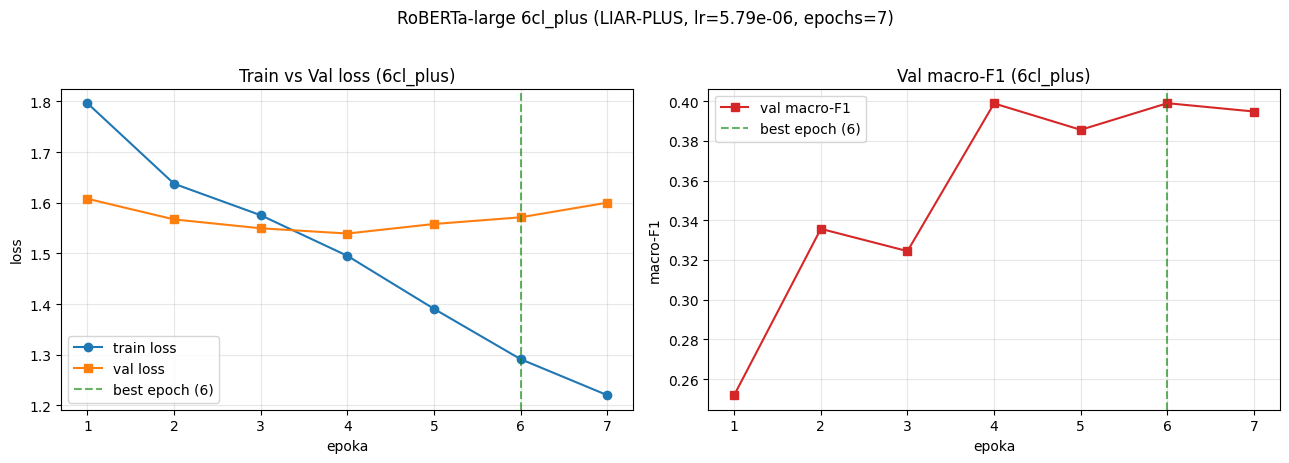

Best epoch: 6 | val_F1=0.3990 | val_loss=1.5714


In [31]:
import matplotlib.pyplot as plt

if history is None:
    print("history is None")
else:
    epochs_x   = list(range(1, len(history['train_loss']) + 1))
    train_loss = history['train_loss']
    val_loss   = history['val_loss']
    val_f1     = history['val_macro_f1']
    best_epoch = max(range(len(val_f1)), key=lambda i: val_f1[i]) + 1

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    ax = axes[0]
    ax.plot(epochs_x, train_loss, marker='o', label='train loss', color='tab:blue')
    ax.plot(epochs_x, val_loss,   marker='s', label='val loss',   color='tab:orange')
    ax.axvline(best_epoch, color='green', linestyle='--', alpha=0.6, label=f'best epoch ({best_epoch})')
    ax.set_xlabel('epoka'); ax.set_ylabel('loss')
    ax.set_title('Train vs Val loss (6cl_plus)')
    ax.set_xticks(epochs_x); ax.grid(alpha=0.3); ax.legend()

    ax = axes[1]
    ax.plot(epochs_x, val_f1, marker='s', label='val macro-F1', color='tab:red')
    ax.axvline(best_epoch, color='green', linestyle='--', alpha=0.6, label=f'best epoch ({best_epoch})')
    ax.set_xlabel('epoka'); ax.set_ylabel('macro-F1')
    ax.set_title('Val macro-F1 (6cl_plus)')
    ax.set_xticks(epochs_x); ax.grid(alpha=0.3); ax.legend()

    plt.suptitle(f'RoBERTa-large 6cl_plus (LIAR-PLUS, lr={best_2cl["lr"]:.2e}, epochs={EPOCHS_PLUS})', y=1.02)
    plt.tight_layout()
    plt.show()

    print(f'Best epoch: {best_epoch} | val_F1={val_f1[best_epoch-1]:.4f} | val_loss={val_loss[best_epoch-1]:.4f}')

=== Test: 6cl_plus / roberta-large (LIAR-PLUS z justification) ===
accuracy           : 0.3828
balanced accuracy  : 0.3833
precision (macro)  : 0.3823   (weighted): 0.3805
recall    (macro)  : 0.3833   (weighted): 0.3828
macro-F1           : 0.3802   weighted-F1: 0.3788

              precision    recall  f1-score   support

  pants-fire      0.398     0.402     0.400        92
       false      0.440     0.490     0.464       249
 barely-true      0.355     0.259     0.300       212
   half-true      0.348     0.302     0.323       265
 mostly-true      0.359     0.452     0.400       241
        true      0.394     0.394     0.394       208

    accuracy                          0.383      1267
   macro avg      0.382     0.383     0.380      1267
weighted avg      0.380     0.383     0.379      1267

ROC AUC (one-vs-rest, macro):    0.7717
ROC AUC (one-vs-rest, weighted): 0.7586


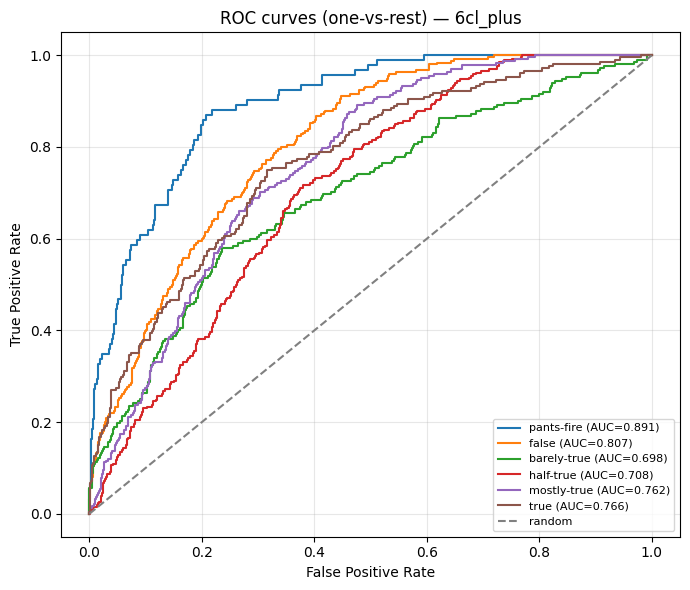


Confusion matrix:
             pants-fire  false  barely-true  half-true  mostly-true  true
pants-fire           37     34            8          7            3     3
false                35    122           32         22           20    18
barely-true          13     40           55         41           27    36
half-true             4     40           34         80           81    26
mostly-true           1     19           13         56          109    43
true                  3     22           13         24           64    82


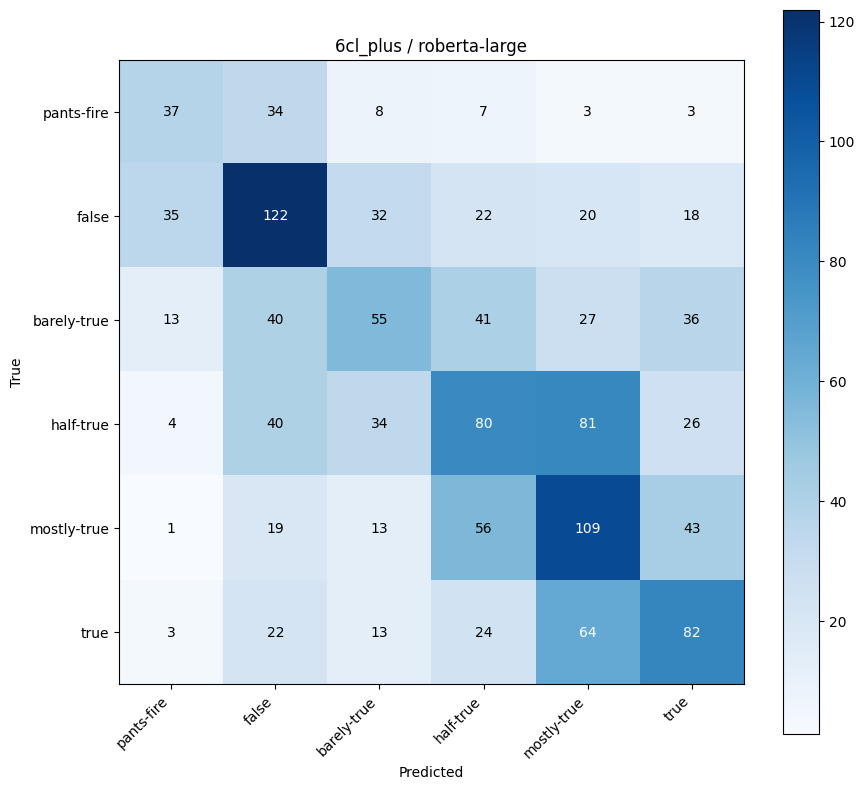

In [32]:
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score,
    balanced_accuracy_score, precision_score, recall_score,
    roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

target_names = LABELS_6

test_loader = torch.utils.data.DataLoader(LiarDataset(enc_test_p, y_test_p),
                                          batch_size=best_2cl['batch_size'], shuffle=False)

model_roberta.eval()
test_preds, test_labels, test_probs = [], [], []
with torch.no_grad():
    for batch in test_loader:
        ids = batch['input_ids'].to(device)
        am  = batch['attention_mask'].to(device)
        logits = model_roberta(ids, attention_mask=am).logits
        probs  = torch.softmax(logits, dim=1)
        p      = torch.argmax(logits, dim=1)
        test_preds.extend(p.cpu().numpy())
        test_labels.extend(batch['labels'].numpy())
        test_probs.extend(probs.cpu().numpy())

test_preds  = np.array(test_preds)
test_labels = np.array(test_labels)
test_probs  = np.array(test_probs)

acc     = accuracy_score(test_labels, test_preds)
bal_acc = balanced_accuracy_score(test_labels, test_preds)
prec_m  = precision_score(test_labels, test_preds, average='macro', zero_division=0)
rec_m   = recall_score(test_labels, test_preds, average='macro', zero_division=0)
mf1     = f1_score(test_labels, test_preds, average='macro')
prec_w  = precision_score(test_labels, test_preds, average='weighted', zero_division=0)
rec_w   = recall_score(test_labels, test_preds, average='weighted', zero_division=0)
wf1     = f1_score(test_labels, test_preds, average='weighted')

print(f'=== Test: 6cl_plus / {MODEL_NAME} (LIAR-PLUS z justification) ===')
print(f'accuracy           : {acc:.4f}')
print(f'balanced accuracy  : {bal_acc:.4f}')
print(f'precision (macro)  : {prec_m:.4f}   (weighted): {prec_w:.4f}')
print(f'recall    (macro)  : {rec_m:.4f}   (weighted): {rec_w:.4f}')
print(f'macro-F1           : {mf1:.4f}   weighted-F1: {wf1:.4f}')
print()
print(classification_report(test_labels, test_preds, target_names=target_names, digits=3, zero_division=0))

auc_macro    = roc_auc_score(test_labels, test_probs, multi_class='ovr', average='macro')
auc_weighted = roc_auc_score(test_labels, test_probs, multi_class='ovr', average='weighted')
print(f'ROC AUC (one-vs-rest, macro):    {auc_macro:.4f}')
print(f'ROC AUC (one-vs-rest, weighted): {auc_weighted:.4f}')

plt.figure(figsize=(7, 6))
for c in range(len(target_names)):
    y_bin = (test_labels == c).astype(int)
    fpr, tpr, _ = roc_curve(y_bin, test_probs[:, c])
    auc_c = roc_auc_score(y_bin, test_probs[:, c])
    plt.plot(fpr, tpr, label=f'{target_names[c]} (AUC={auc_c:.3f})', lw=1.5)
plt.plot([0, 1], [0, 1], '--', color='gray', label='random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title(f'ROC curves (one-vs-rest) — 6cl_plus')
plt.grid(alpha=0.3); plt.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()

cm = confusion_matrix(test_labels, test_preds)
print('\nConfusion matrix:')
print(pd.DataFrame(cm, index=target_names, columns=target_names))

fig, ax = plt.subplots(figsize=(1.2*len(target_names)+2, 1.2*len(target_names)+1))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(target_names))); ax.set_xticklabels(target_names, rotation=45, ha='right')
ax.set_yticks(range(len(target_names))); ax.set_yticklabels(target_names)
for i in range(len(target_names)):
    for j in range(len(target_names)):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black')
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(f'6cl_plus / {MODEL_NAME}')
fig.colorbar(im); fig.tight_layout(); plt.show()